# Baseline de disputas de transacciones
Hackathon Factored AI & Data 2026. Este notebook fija el **baseline** contra el que se medirá el sistema de intake de disputas.

Tiene tres partes:
1. **Contrato y calidad de datos** de las tablas que usamos.
2. **Baseline operativo** de la atención humana de disputas (volumen, SLA, resolución, compensación).
3. **Baseline de triaje de riesgo** sobre transacciones, con split temporal y comparación reglas vs. score vs. modelo.

**Definiciones del equipo (no vienen del organizador):**
- *Disputa* = queja en `complaints` con `subcategory` en `Cargo no reconocido` o `Cobro indebido`.
- Las descripciones de las quejas son plantillas y `origin_interaction_id` es 100% nulo. No hay `transaction_id` en las quejas, así que **no podemos ligar una disputa a una transacción concreta**.
- Todo lo que sigue es **offline sobre datos sintéticos**. No es una mejora medida en producción.

In [1]:
import sys, pandas as pd, numpy as np, matplotlib.pyplot as plt, json, warnings
from pathlib import Path
from IPython.display import display
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
HERE = Path('.').resolve()                      # analysis/notebooks (el notebook se ejecuta aqui)
sys.path.insert(0, str(HERE.parent))
from paths import RAW as DATA, WORK as AN       # ver analysis/paths.py (HACKATHON_RAW_DIR / HACKATHON_WORK_DIR)
OUT = HERE / 'outputs'; OUT.mkdir(exist_ok=True)
SEED = 42
DISPUTE_SUBCATS = ['Cargo no reconocido', 'Cobro indebido']
COUNTRY_FIX = {'Mexico': 'México'}

## 1. Carga y contrato de datos

In [2]:
cp = pd.read_parquet(AN/'complaints.parquet')
cc = pd.read_parquet(AN/'call_center_interactions.parquet')
tx = pd.read_parquet(AN/'transactions.parquet')
cu = pd.read_csv(DATA/'customers.csv', encoding='utf-8-sig')

for c in ['creation_date','assignment_date','first_response_date','resolution_date','closing_date']:
    cp[c] = pd.to_datetime(cp[c])
for c in ['claimed_amount','resolution_days','compensation_granted','resolution_satisfaction']:
    cp[c] = pd.to_numeric(cp[c])
for c in ['sla_breached','is_repeat_complainer']:
    cp[c] = cp[c] == 'True'
cp['is_dispute'] = cp.subcategory.isin(DISPUTE_SUBCATS)
cp = cp.merge(cu[['customer_id','country','segment']], on='customer_id', how='left')
cp['country'] = cp.country.replace(COUNTRY_FIX)
print(f'quejas: {len(cp):,} | disputas: {cp.is_dispute.sum():,} ({cp.is_dispute.mean():.1%})')

quejas: 67,095 | disputas: 24,491 (36.5%)


In [3]:
has_res = cp.resolution_date.notna()
checks = {
 'complaints: PK única': cp.complaint_id.is_unique,
 'complaints: customer_id existe en customers': cp.customer_id.isin(cu.customer_id).all(),
 'complaints: fechas dentro de 2023-06-17..2026-06-18': cp.creation_date.between('2023-06-17','2026-06-19').all(),
 'complaints: resolution_date >= creation_date': (cp.loc[has_res,'resolution_date'] >= cp.loc[has_res,'creation_date']).all(),
 'complaints: claimed_amount >= 0': (cp.claimed_amount.dropna() >= 0).all(),
 'transactions: PK única': tx.transaction_id.is_unique,
 'transactions: customer_id existe': tx.customer_id.isin(cu.customer_id).all(),
 'transactions: país sin variantes Mexico/México': tx.transaction_country.nunique() == tx.transaction_country.replace(COUNTRY_FIX).nunique(),
}
qc = pd.Series(checks, name='ok').to_frame()
qc['ok'] = qc.ok.map({True:'PASS', False:'FAIL'})
qc

,ok
complaints: PK única,PASS
complaints: customer_id existe en customers,PASS
complaints: fechas dentro de 2023-06-17..2026-06-18,PASS
complaints: resolution_date >= creation_date,PASS
complaints: claimed_amount >= 0,PASS
transactions: PK única,PASS
transactions: customer_id existe,PASS
transactions: país sin variantes Mexico/México,FAIL


In [4]:
nulls = cp[cp.is_dispute].isna().mean().round(3)
print('Nulos en disputas (fracción):')
nulls[nulls > 0].sort_values(ascending=False)

Nulos en disputas (fracción):


origin_interaction_id      1.000
resolution_satisfaction    0.964
closing_date               0.963
compensation_granted       0.929
resolution                 0.772
resolution_date            0.771
resolution_days            0.770
related_branch_id          0.712
claimed_amount             0.668
currency                   0.668
first_response_date        0.388
assignment_date            0.341
assigned_agent_id          0.339
affected_product_id        0.336
dtype: float64

## 2. Baseline operativo: atención humana de disputas
Es la referencia para medir "mejor servicio". Se compara la disputa con el resto de las quejas.

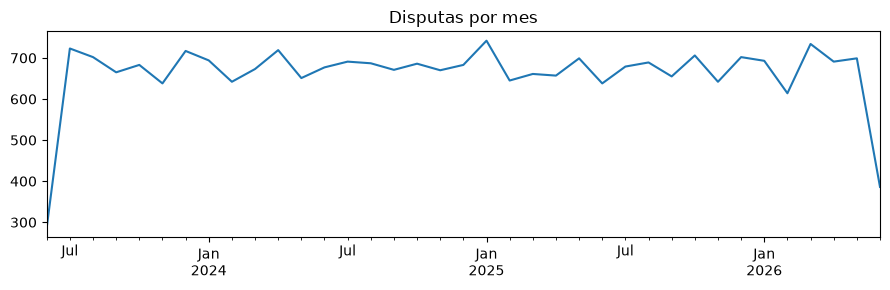

Promedio mensual: 662 | min 287 | max 742


subcategory,Cargo no reconocido,Cobro indebido,All
country,,,
Argentina,2421,2456,4877
Colombia,3727,3788,7515
México,6149,5950,12099
All,12297,12194,24491


In [5]:
d = cp[cp.is_dispute].copy()
d['month'] = d.creation_date.dt.to_period('M')
vol = d.groupby('month').size()
ax = vol.plot(figsize=(9,3), title='Disputas por mes'); ax.set_xlabel(''); plt.tight_layout(); plt.show()
print('Promedio mensual:', round(vol.mean()), '| min', vol.min(), '| max', vol.max())
pd.crosstab(d.country, d.subcategory, margins=True)

In [6]:
def ops_metrics(x):
    closed = x[x.resolution_date.notna()]
    fr = (x.first_response_date - x.creation_date).dt.total_seconds()/3600
    return pd.Series({
      'casos': len(x),
      'con_resolucion_%': 100*x.resolution_date.notna().mean(),
      'sla_incumplido_%': 100*x.sla_breached.mean(),
      'resolucion_dias_p50': closed.resolution_days.median(),
      'resolucion_dias_p95': closed.resolution_days.quantile(.95),
      '1a_respuesta_horas_p50': fr.median(),
      'escalados_%': 100*(x.status=='Escalated').mean(),
      'rechazados_%': 100*(x.status=='Rejected').mean(),
      'con_compensacion_%': 100*x.compensation_granted.notna().mean(),
      'satisfaccion_media': x.resolution_satisfaction.mean(),
      'reincidentes_%': 100*x.is_repeat_complainer.mean(),
      'monto_reclamado_mediana': x.claimed_amount.median(),
    })
base_ops = pd.concat({
  'Disputas': ops_metrics(cp[cp.is_dispute]),
  'Cargo no reconocido': ops_metrics(cp[cp.subcategory=='Cargo no reconocido']),
  'Cobro indebido': ops_metrics(cp[cp.subcategory=='Cobro indebido']),
  'Otras quejas': ops_metrics(cp[~cp.is_dispute]),
}, axis=1).round(2)
base_ops

,Disputas,Cargo no reconocido,Cobro indebido,Otras quejas
casos,24491.00,12297.00,12194.00,42604.00
con_resolucion_%,22.93,23.33,22.52,22.85
sla_incumplido_%,20.16,20.39,19.94,20.08
resolucion_dias_p50,16.00,15.00,16.00,16.00
resolucion_dias_p95,29.00,29.00,29.00,29.00
1a_respuesta_horas_p50,37.00,37.00,38.00,38.00
escalados_%,5.12,5.03,5.21,4.85
rechazados_%,0.96,0.90,1.01,1.11
con_compensacion_%,7.15,7.39,6.91,6.78
satisfaccion_media,3.03,3.07,2.99,3.02


In [7]:
print('Estado de las disputas (%):', (d.status.value_counts(normalize=True)*100).round(1).to_dict())
print('Prioridad (%):', (d.priority.value_counts(normalize=True)*100).round(1).to_dict())
by_country = d.groupby('country').agg(casos=('complaint_id','size'), sla_incumplido=('sla_breached','mean'),
                                       res_dias_p50=('resolution_days','median'),
                                       escalados=('status', lambda s:(s=='Escalated').mean())).round(3)
by_seg = d.groupby('segment').agg(casos=('complaint_id','size'), sla_incumplido=('sla_breached','mean'),
                                   escalados=('status', lambda s:(s=='Escalated').mean())).round(3)
display(by_country); display(by_seg)

Estado de las disputas (%): {'In Process': 40.1, 'Open': 29.7, 'Resolved': 20.3, 'Escalated': 5.1, 'Closed': 3.8, 'Rejected': 1.0}
Prioridad (%): {'Medium': 49.7, 'Low': 30.6, 'High': 14.8, 'Critical': 4.9}


,casos,sla_incumplido,res_dias_p50,escalados
country,,,,
Argentina,4877,0.202,16.0,0.053
Colombia,7515,0.198,16.0,0.048
México,12099,0.204,15.0,0.052


,casos,sla_incumplido,escalados
segment,,,
Basic,14689,0.202,0.052
Plus,6130,0.207,0.053
Premium,2461,0.198,0.046
Student,1211,0.180,0.045


In [8]:
# ¿El tiempo de resolución depende de la categoría o prioridad? Si no, no hay señal para predecirlo.
r = cp.dropna(subset=['resolution_days'])
print(r.groupby('is_dispute').resolution_days.describe().round(1))
print('mediana por prioridad:', r.groupby('priority').resolution_days.median().to_dict())

             count  mean  std  min  25%   50%   75%   max
is_dispute                                               
False       9740.0  15.7  8.7  1.0  8.0  16.0  23.0  30.0
True        5623.0  15.5  8.7  1.0  8.0  15.0  23.0  30.0
mediana por prioridad: {'Critical': 15.0, 'High': 16.0, 'Low': 16.0, 'Medium': 16.0}


### Contexto del contact center (no ligable a disputas)
`contact_reason` repite `reason_category` (6 valores) y `origin_interaction_id` está vacío en las quejas, así que solo sirve como contexto de canal.

In [9]:
for c in ['was_resolved','was_escalated','requires_followup']: cc[c] = cc[c]=='True'
cc['wait'] = pd.to_numeric(cc.wait_time_seconds); cc['dur'] = pd.to_numeric(cc.duration_seconds)
cc_base = cc.groupby('reason_category').agg(interacciones=('interaction_id','size'), fcr=('was_resolved','mean'),
        escaladas=('was_escalated','mean'), seguimiento=('requires_followup','mean'),
        espera_p50_s=('wait','median'), duracion_p50_s=('dur','median')).round(3)
cc_base

,interacciones,fcr,escaladas,seguimiento,espera_p50_s,duracion_p50_s
reason_category,,,,,,
Comercial,54879,0.652,0.098,0.445,120.0,540.0
Producto,150863,0.896,0.100,0.238,119.0,263.0
Queja,117021,0.436,0.100,0.630,120.0,431.0
Retención,20578,0.602,0.098,0.491,120.0,478.0
Transaccional,240056,0.915,0.099,0.221,119.0,205.0
Técnico,102899,0.699,0.101,0.406,119.0,360.0


## 3. Baseline de triaje de riesgo en transacciones
Pregunta: ¿qué tan bien se priorizan las transacciones sospechosas antes de que un humano las revise?

- **Etiqueta:** `is_fraud` (0,1% positivos). Es una etiqueta sintética del organizador. Se declara como tal.
- **Split temporal** (evita fuga por tiempo): entrenamiento < 2025-07, validación 2025-07..2025-12, prueba >= 2026-01.
- **Umbrales** elegidos **solo en validación**, aplicados una vez sobre prueba.
- **Métricas:** PR-AUC (por el desbalance), recall y precisión con un presupuesto de revisión fijo (top 1% de las transacciones).
- **Fuga:** `fraud_score` es un score generado por el organizador. Se usa como *baseline de referencia* (B2) y en una variante explícita del modelo (M2). M1 no lo usa.

In [10]:
tx['transaction_date'] = pd.to_datetime(tx.transaction_date)
tx['y'] = (tx.is_fraud=='True').astype(int)
tx['amount'] = pd.to_numeric(tx.amount)
tx['fraud_score'] = pd.to_numeric(tx.fraud_score)
tx['transaction_country'] = tx.transaction_country.replace(COUNTRY_FIX)
tx = tx.merge(cu[['customer_id','country']].rename(columns={'country':'home_country'}), on='customer_id', how='left')
tx['home_country'] = tx.home_country.replace(COUNTRY_FIX)
tx['foreign'] = (tx.transaction_country != tx.home_country).astype(int)
tx['hour'] = tx.transaction_date.dt.hour
tx['dow'] = tx.transaction_date.dt.dayofweek
tx['is_declined'] = (tx.transaction_status=='Declined').astype(int)
tx['log_amount'] = np.log1p(tx.amount.clip(lower=0))

train = tx[tx.transaction_date < '2025-07-01']
val   = tx[(tx.transaction_date >= '2025-07-01') & (tx.transaction_date < '2026-01-01')]
test  = tx[tx.transaction_date >= '2026-01-01']
split = pd.DataFrame({'filas':[len(train),len(val),len(test)], 'fraudes':[train.y.sum(),val.y.sum(),test.y.sum()]},
                     index=['train','val','test'])
split['tasa_fraude_%'] = (100*split.fraudes/split.filas).round(3)
split

,filas,fraudes,tasa_fraude_%
train,2994597,3014,0.101
val,743909,699,0.094
test,686502,603,0.088


In [11]:
from sklearn.metrics import average_precision_score, roc_auc_score
BUDGET = 0.01  # revisar el 1% con mayor riesgo
rng = np.random.default_rng(SEED)

def val_thr(s_val): return np.quantile(np.nan_to_num(s_val, nan=-1.0), 1-BUDGET)

def eval_scores(name, y, s, thr):
    s = np.nan_to_num(s, nan=-1.0)
    flag = s >= thr
    tp = int((flag & (y==1)).sum())
    return dict(modelo=name, pr_auc=average_precision_score(y, s), roc_auc=roc_auc_score(y, s),
                alertas_pct=100*flag.mean(), recall=tp/max(int(y.sum()),1),
                precision=tp/max(int(flag.sum()),1), umbral=thr)

rows = []
# B0: aleatorio
s0_val, s0_test = rng.random(len(val)), rng.random(len(test))
rows.append(eval_scores('B0 aleatorio', test.y.values, s0_test, val_thr(s0_val)))
# B1: regla simple (extranjero, rechazada, monto alto). Umbral de monto tomado en train.
amt_thr = train.amount.quantile(.95)
def rule_score(df, seed):
    g = np.random.default_rng(seed).random(len(df))*1e-3   # desempate
    return (df.foreign*2 + df.is_declined + (df.amount > amt_thr).astype(int)).values.astype(float) + g
rows.append(eval_scores('B1 regla (extranjero/rechazo/monto)', test.y.values, rule_score(test,1), val_thr(rule_score(val,2))))
# B2: fraud_score del organizador
rows.append(eval_scores('B2 fraud_score', test.y.values, test.fraud_score.values, val_thr(val.fraud_score.values)))
print('fraud_score nulo en test: %.1f%%' % (100*test.fraud_score.isna().mean()))

fraud_score nulo en test: 20.0%


In [12]:
from sklearn.ensemble import HistGradientBoostingClassifier
FEATS_NUM = ['log_amount','hour','dow','foreign','is_declined']
FEATS_CAT = ['transaction_type','channel','transaction_country','currency','transaction_status']
cats = {c: pd.Categorical(tx[c]).categories for c in FEATS_CAT}
def prep(df, with_score=False):
    X = df[FEATS_NUM].copy()
    for c in FEATS_CAT: X[c] = pd.Categorical(df[c], categories=cats[c])
    if with_score: X['fraud_score'] = df.fraud_score.values
    return X

# Submuestreo de negativos SOLO en entrenamiento (val/test intactos)
neg = train[train.y==0].sample(400_000, random_state=SEED); pos = train[train.y==1]
tr = pd.concat([neg,pos]).sample(frac=1, random_state=SEED)
def fit(with_score):
    m = HistGradientBoostingClassifier(max_iter=200, learning_rate=.08, categorical_features='from_dtype', random_state=SEED)
    return m.fit(prep(tr, with_score), tr.y)
m1, m2 = fit(False), fit(True)
p1_val, p1_test = m1.predict_proba(prep(val))[:,1], m1.predict_proba(prep(test))[:,1]
p2_val, p2_test = m2.predict_proba(prep(val,True))[:,1], m2.predict_proba(prep(test,True))[:,1]
rows.append(eval_scores('M1 GBM sin fraud_score', test.y.values, p1_test, val_thr(p1_val)))
rows.append(eval_scores('M2 GBM con fraud_score', test.y.values, p2_test, val_thr(p2_val)))
res = pd.DataFrame(rows).set_index('modelo').round(4)
res

,pr_auc,roc_auc,alertas_pct,recall,precision,umbral
modelo,,,,,,
B0 aleatorio,0.0009,0.4968,1.0057,0.0050,0.0004,0.9900
B1 regla (extranjero/rechazo/monto),0.0009,0.4929,1.0128,0.0066,0.0006,2.0009
B2 fraud_score,0.5769,0.7232,1.0124,0.5804,0.0504,29.6500
M1 GBM sin fraud_score,0.0009,0.5087,0.9905,0.0149,0.0013,0.0134
M2 GBM con fraud_score,0.5199,0.8412,0.9895,0.5738,0.0509,0.0138


In [13]:
# Incertidumbre: IC95 bootstrap del PR-AUC en test. Se remuestrea sobre todos los positivos y una muestra de negativos
# (con pocos positivos, la varianza es alta).
pos_t = test[test.y==1].index; neg_t = test[test.y==0].sample(300_000, random_state=SEED).index
idx_all = np.concatenate([pos_t, neg_t])
sc = {'B2 fraud_score': test.fraud_score, 'M1': pd.Series(p1_test, index=test.index), 'M2': pd.Series(p2_test, index=test.index)}
print('positivos en test:', len(pos_t))
for name, s in sc.items():
    yy, ss = test.y.loc[idx_all].values, np.nan_to_num(s.loc[idx_all].values, nan=-1.0)
    out = []
    for _ in range(100):
        b = rng.integers(0, len(yy), len(yy))
        if yy[b].sum(): out.append(average_precision_score(yy[b], ss[b]))
    print(f'{name}: PR-AUC IC95 {np.percentile(out,[2.5,97.5]).round(3)} (con negativos submuestreados; solo comparativo)')

positivos en test: 603


B2 fraud_score: PR-AUC IC95 [0.545 0.624] (con negativos submuestreados; solo comparativo)


M1: PR-AUC IC95 [0.002 0.002] (con negativos submuestreados; solo comparativo)


M2: PR-AUC IC95 [0.504 0.575] (con negativos submuestreados; solo comparativo)


In [14]:
# Rendimiento por país del cliente (mejor variante, M2), con el umbral fijado en validación
thr = val_thr(p2_val)
te = test.assign(score=p2_test)
seg = te.groupby('home_country').apply(lambda g: pd.Series({
    'filas': len(g), 'fraudes': int(g.y.sum()),
    'recall': ((g.score>=thr)&(g.y==1)).sum()/max(g.y.sum(),1),
    'alertas_pct': 100*(g.score>=thr).mean()})).round(3)
seg

,filas,fraudes,recall,alertas_pct
home_country,,,,
Argentina,136279.0,127.0,0.598,1.146
Colombia,206311.0,163.0,0.558,0.945
México,343912.0,313.0,0.572,0.954


## 4. Resumen del baseline y límites
Se guardan las cifras en `outputs/baseline_summary.json` para compararlas con el sistema propuesto **sobre la misma carga de prueba**.

In [15]:
summary = {
  'definicion_disputa': DISPUTE_SUBCATS,
  'operativo_disputas': base_ops['Disputas'].to_dict(),
  'operativo_otras_quejas': base_ops['Otras quejas'].to_dict(),
  'triaje_test': res.reset_index().to_dict(orient='records'),
  'split': split.reset_index().rename(columns={'index':'split'}).to_dict(orient='records'),
  'presupuesto_revision': BUDGET, 'seed': SEED,
  'limites': [
    'Datos sintéticos; etiquetas is_fraud/fraud_score son del organizador.',
    'Quejas sin transaction_id ni texto libre: no se puede etiquetar una disputa contra una transacción.',
    'Pocos positivos de fraude (0,1%); resultados con alta varianza.',
    'Medición offline, no mejora en producción.',
  ]}
(OUT/'baseline_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2, default=float), encoding='utf-8')
print('guardado', OUT/'baseline_summary.json')

guardado C:\dev\hackathon\repo\analysis\notebooks\outputs\baseline_summary.json


### Cómo usarlo
- El sistema de intake se compara contra la columna `Disputas` del baseline operativo: SLA incumplido, resolución en días, escalamiento y compensación.
- Para el componente aprendido, el modelo debe superar B2 (`fraud_score`) y M1 a igual presupuesto de revisión. Si no, la respuesta honesta es reglas más score.
- Antes de reportar mejoras, ampliar la prueba con casos generados por el equipo en español y portugués, etiquetados con criterio humano.